In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 1. Import Libraries
# ==============================
import pandas as pd
import numpy as np
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt

In [3]:
# ==============================
# 2. Load Dataset
# ==============================
df = pd.read_csv(
    '/content/drive/My Drive/Colab Notebooks/Research/Diabetes/diabetes_012_health_indicators_BRFSS2015.csv'
)

print("Dataset Shape:", df.shape)

Dataset Shape: (253680, 22)


In [4]:
# ==============================
# 3. Features & Target
# ==============================
X = df.drop(['Diabetes_012', 'AnyHealthcare'], axis=1)
y = df['Diabetes_012']

# ==============================
# 4. Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [5]:
# ==============================
# 5. Feature Scaling
# ==============================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Before SMOTE:")
print(pd.Series(y_train).value_counts())


# ==============================
# 6. Apply SMOTE (Only on Training Data)
# ==============================
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_train).value_counts())

Before SMOTE:
Diabetes_012
0.0    149592
2.0     24742
1.0      3242
Name: count, dtype: int64
After SMOTE:
Diabetes_012
0.0    149592
2.0    149592
1.0    149592
Name: count, dtype: int64


In [6]:
# ==============================
# 7. Train Model
# ==============================
model = LogisticRegression(
    max_iter=1000,
    multi_class='multinomial'
)

model.fit(X_train, y_train)


# ==============================
# 8. Evaluate Model
# ==============================
accuracy = model.score(X_test, y_test)

print("\nTest Accuracy:", accuracy)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Test Accuracy: 0.6406496373383791


In [7]:
# ==============================
# 9. Predictions
# ==============================
y_pred = model.predict(X_test)

In [8]:
# ==============================
# 10. Metrics
# ==============================
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[42123 11461 10527]
 [  376   436   577]
 [ 1788  2619  6197]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.66      0.78     64111
         1.0       0.03      0.31      0.05      1389
         2.0       0.36      0.58      0.44     10604

    accuracy                           0.64     76104
   macro avg       0.45      0.52      0.43     76104
weighted avg       0.85      0.64      0.72     76104



In [9]:
# Manual Metrics
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("\nPrecision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Precision: 0.8517065696244013
Recall: 0.6406496373383791
F1 Score: 0.7176027388017829


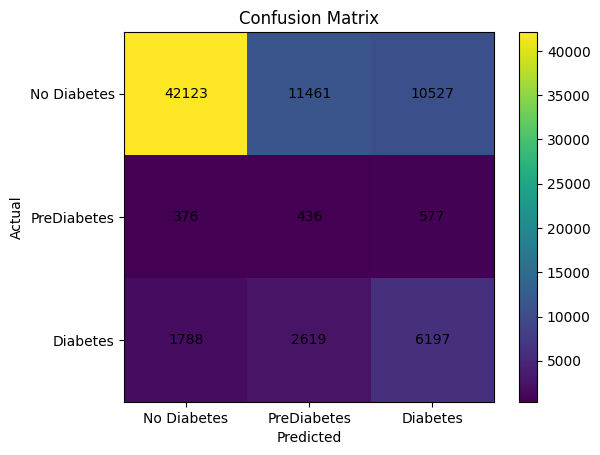

In [10]:
# ==============================
# 11. Confusion Matrix Visualization
# ==============================
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

# Labels
classes = ['No Diabetes', 'PreDiabetes', 'Diabetes']
tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

# Annotate values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()